In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

In [ ]:
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (426, 30)
Testing samples: (143, 30)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [ ]:
y_pred = knn_model.predict(X_test)
print("Predicted:", y_pred[:10])
print("Actual:", y_test.values[:10])

Predicted: ['M' 'B' 'M' 'B' 'M' 'B' 'B' 'B' 'B' 'B']
Actual: [['M']
 ['B']
 ['M']
 ['B']
 ['B']
 ['B']
 ['B']
 ['B']
 ['B']
 ['B']]


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9230769230769231


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[89  1]
 [10 43]]


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.90      0.99      0.94        90
           M       0.98      0.81      0.89        53

    accuracy                           0.92       143
   macro avg       0.94      0.90      0.91       143
weighted avg       0.93      0.92      0.92       143



In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
y_prob = knn_model.predict_proba(X_test)[:,1]

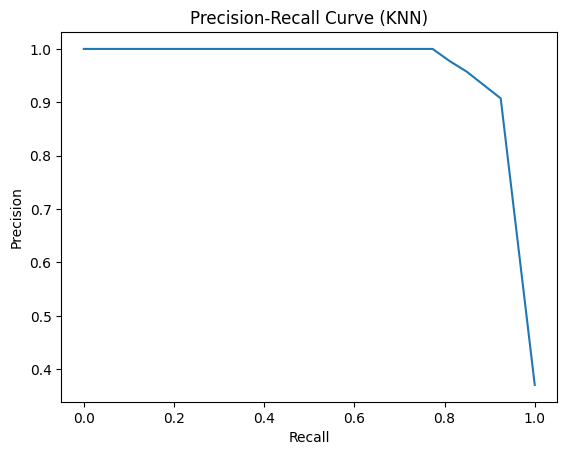

In [ ]:
import numpy as np

# Convert y_test to numerical labels: 'M' -> 1, 'B' -> 0
y_test_numeric = np.where(y_test.values.ravel() == 'M', 1, 0)

precision, recall, thresholds = precision_recall_curve(y_test_numeric, y_prob, pos_label=1)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (KNN)")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve

In [ ]:
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
svm_model = SVC(kernel='linear', probability=True)

svm_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', probability=True)

In [ ]:
y_pred = svm_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9370629370629371


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[88  2]
 [ 7 46]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           B       0.93      0.98      0.95        90
           M       0.96      0.87      0.91        53

    accuracy                           0.94       143
   macro avg       0.94      0.92      0.93       143
weighted avg       0.94      0.94      0.94       143



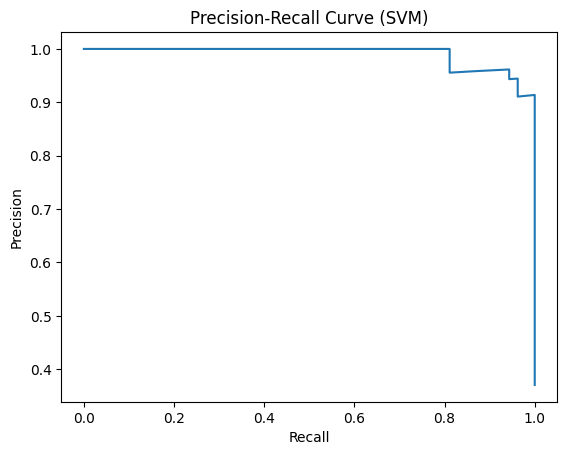

In [ ]:
y_prob = svm_model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test_numeric, y_prob, pos_label=1)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (SVM)")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train))
knn_train_acc = accuracy_score(y_train, knn_model.predict(X_train))

In [ ]:
# Testing accuracy
svm_test_acc = accuracy_score(y_test, svm_model.predict(X_test))
knn_test_acc = accuracy_score(y_test, knn_model.predict(X_test))

In [ ]:
print("SVM Train Accuracy:", svm_train_acc)
print("SVM Test Accuracy:", svm_test_acc)

print("KNN Train Accuracy:", knn_train_acc)
print("KNN Test Accuracy:", knn_test_acc)

SVM Train Accuracy: 0.9694835680751174
SVM Test Accuracy: 0.9370629370629371
KNN Train Accuracy: 0.9483568075117371
KNN Test Accuracy: 0.9230769230769231


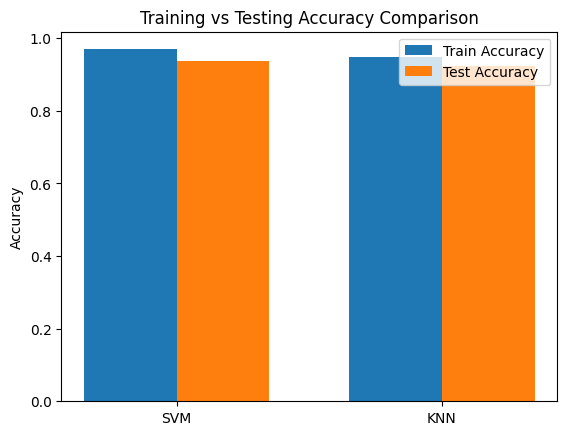

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ['SVM', 'KNN']
train_scores = [svm_train_acc, knn_train_acc]
test_scores = [svm_test_acc, knn_test_acc]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, train_scores, width, label='Train Accuracy')
plt.bar(x + width/2, test_scores, width, label='Test Accuracy')

plt.xticks(x, models)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

In [ ]:
svm_prob = svm_model.predict_proba(X_test)[:,1]
knn_prob = knn_model.predict_proba(X_test)[:,1]

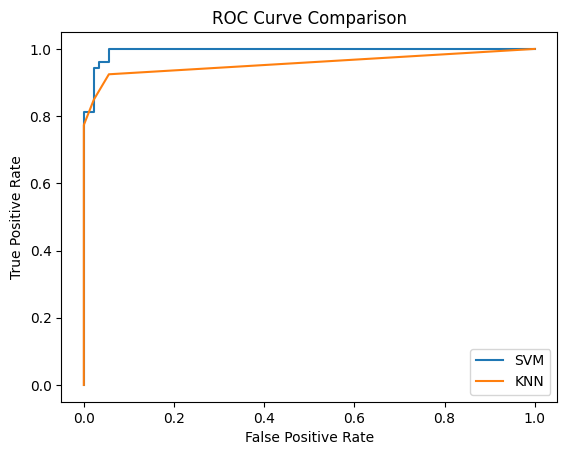

In [ ]:
fpr_svm, tpr_svm, _ = roc_curve(y_test_numeric, svm_prob, pos_label=1)
fpr_knn, tpr_knn, _ = roc_curve(y_test_numeric, knn_prob, pos_label=1)

plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_knn, tpr_knn, label="KNN")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, svm_model.predict(X_test))
cm_knn = confusion_matrix(y_test, knn_model.predict(X_test))

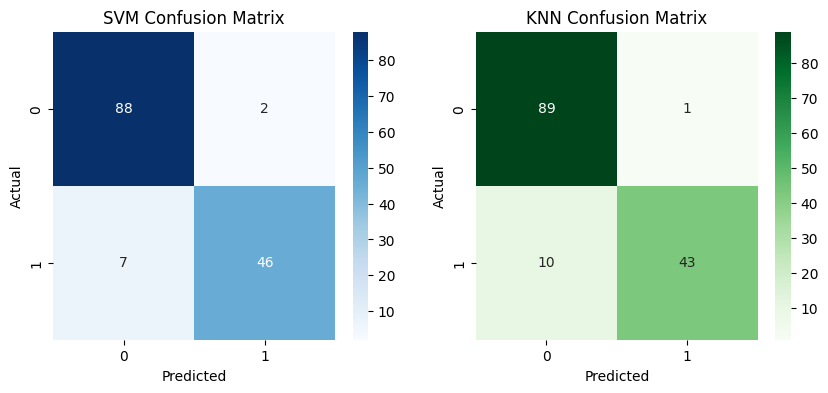

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1,2,2)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()